In [4]:
%cd /content/gdrive/MyDrive/stock-predictions
!git pull

/content/gdrive/MyDrive/stock-predictions
Already up to date.


Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


Clone Repo

In [ ]:
import os

repo_url = "https://YOUR_TOKEN@github.com/augusthao6/stock-predictions.git"
gdrive_repo_path = "/content/gdrive/MyDrive/stock-predictions"

%cd /content/gdrive/MyDrive/

if not os.path.exists(gdrive_repo_path + "/.git"):
    # Either doesn't exist or exists but isn't a git repo — clone fresh
    !rm -rf {gdrive_repo_path}
    !git clone {repo_url} stock-predictions
else:
    print("Repo already exists, pulling latest changes...")
    %cd {gdrive_repo_path}
    !git pull

/content/gdrive/MyDrive
Cloning into 'stock-predictions'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 68 (delta 1), reused 68 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 111.99 KiB | 2.15 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [2]:
%cd /content/gdrive/MyDrive/stock-predictions

/content/gdrive/MyDrive/stock-predictions


# Data collection and preprocessing

In [3]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data.collector import StockDataCollector
from src.data.preprocessor import DataPreprocessor
from src.features.technical import TechnicalIndicators

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'JPM', 'GS', 'SPY', 'QQQ']
print('Setup complete')

Setup complete


Collect data through yfinance API

In [4]:
collector = StockDataCollector(tickers=TICKERS)
prices = collector.download_prices(start='2017-04-26', end='2026-04-26', force_refresh=True)

summary = collector.get_collection_summary(prices)
print('Collection Summary:')
for k, v in summary.items():
    print(f'  {k}: {v}')

print(f'\nDataFrame shape: {prices.shape}')
print(f'Date range: {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Trading days: {len(prices)}')

Collection Summary:
  tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'JPM', 'GS', 'SPY', 'QQQ']
  n_tickers: 10
  date_range: 2017-04-26 to 2026-04-24
  n_trading_days: 2262
  total_observations: 22620
  fields: ['Open', 'High', 'Low', 'Close', 'Volume']
  source: Yahoo Finance API via yfinance
  collection_method: Programmatic API integration with retry logic and caching

DataFrame shape: (2262, 50)
Date range: 2017-04-26 to 2026-04-24
Trading days: 2262


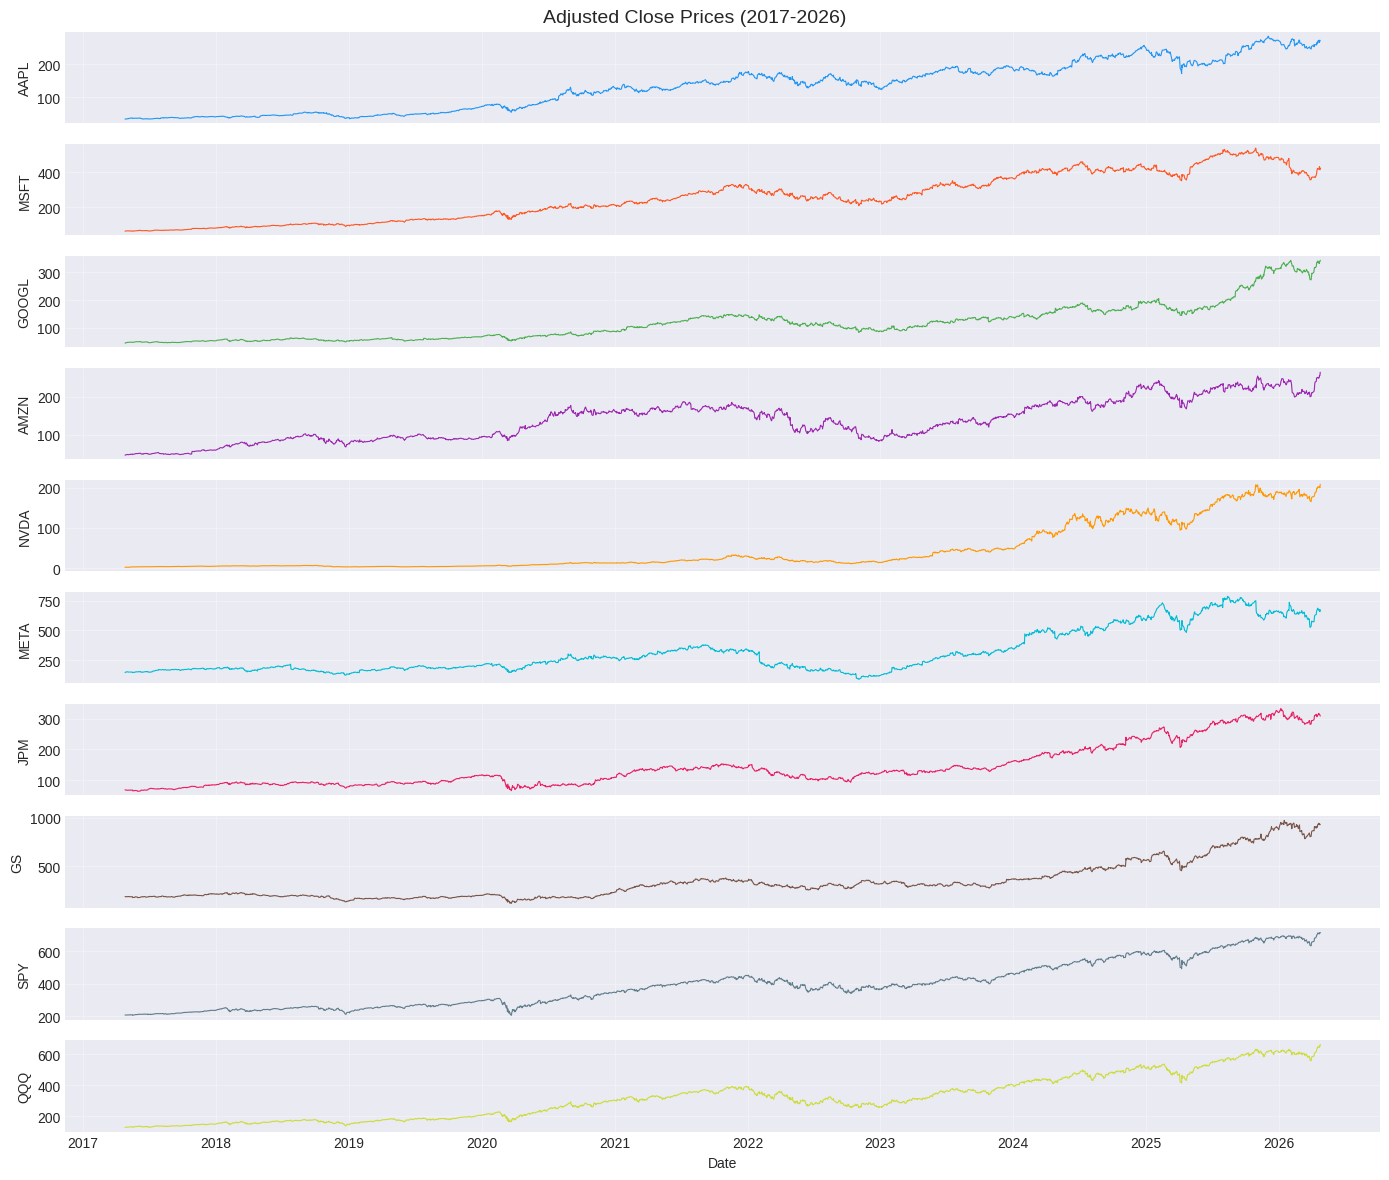

In [27]:
import os

# Plot adjusted close prices for all tickers
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 12), sharex=True)
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548', '#607D8B', '#CDDC39']

for i, (ticker, color) in enumerate(zip(TICKERS, colors)):
    close = prices[ticker]['Close']
    axes[i].plot(close.index, close.values, color=color, linewidth=0.8)
    axes[i].set_ylabel(ticker)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Adjusted Close Prices (2017-2026)', fontsize=14)
plt.tight_layout()

# Ensure the directory exists before saving
os.makedirs('/docs', exist_ok=True)
plt.savefig('/docs/price_history.png', dpi=150, bbox_inches='tight')
plt.show()

Missing Value Analysis

In [28]:
preprocessor = DataPreprocessor()

# Check missing values per ticker/field
missing_stats = []
for ticker in TICKERS:
    ohlcv = prices[ticker]
    n_missing = ohlcv.isnull().sum().sum()
    n_total = ohlcv.size
    missing_stats.append({'Ticker': ticker, 'Missing': n_missing, 'Total': n_total,
                          'Missing %': f'{100*n_missing/n_total:.3f}%'})

missing_df = pd.DataFrame(missing_stats)
print('Missing Value Analysis (before imputation):')
print(missing_df.to_string(index=False))

# After imputation
aapl_clean, mv_stats = preprocessor.handle_missing_values(prices['AAPL'].copy())
print(f'\nImputation stats for AAPL: {mv_stats}')

Missing Value Analysis (before imputation):
Ticker  Missing  Total Missing %
  AAPL        0  11310    0.000%
  MSFT        0  11310    0.000%
 GOOGL        0  11310    0.000%
  AMZN        0  11310    0.000%
  NVDA        0  11310    0.000%
  META        0  11310    0.000%
   JPM        0  11310    0.000%
    GS        0  11310    0.000%
   SPY        0  11310    0.000%
   QQQ        0  11310    0.000%

Imputation stats for AAPL: {'missing_before': 0, 'missing_after': 0, 'imputed': 0, 'imputation_rate': 0.0}


Outlier Analysis

Outlier stats: {'outliers_clipped': 24, 'iqr_multiplier': 3.0, 'clip_bounds_sample': {'Return': {'lower': -0.061303008657644265, 'upper': 0.06404824201160919}}}


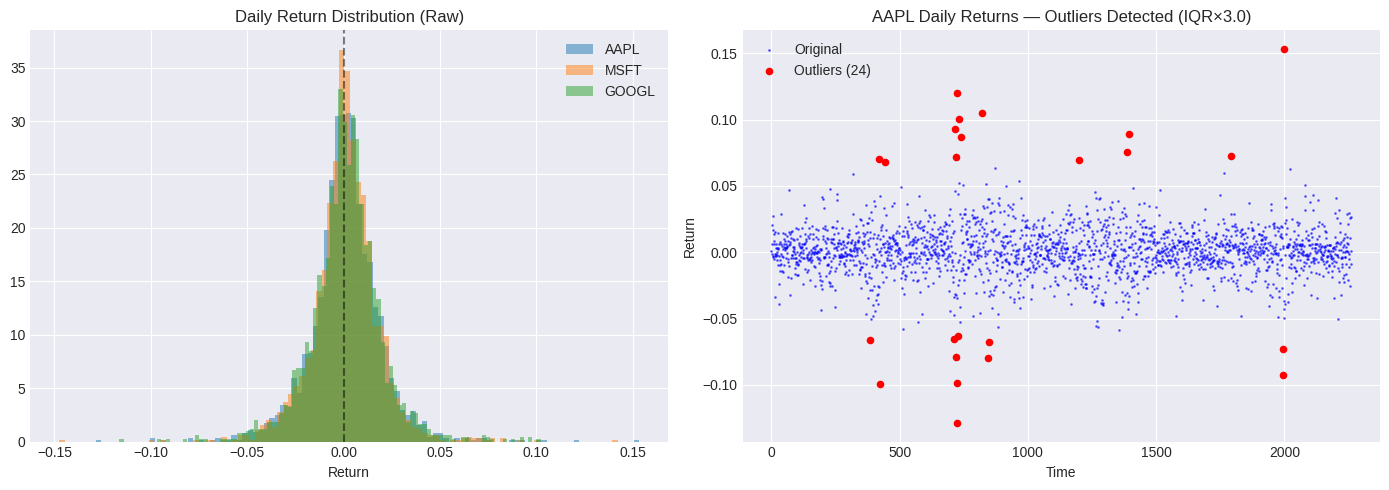

In [29]:
# Compute returns and identify outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ticker in TICKERS[:3]:
    close = prices[ticker]['Close'].dropna()
    returns = close.pct_change().dropna()
    axes[0].hist(returns, bins=100, alpha=0.5, label=ticker, density=True)

axes[0].set_title('Daily Return Distribution (Raw)')
axes[0].set_xlabel('Return')
axes[0].legend()
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.5)

# Identify outliers using IQR
aapl_returns = prices['AAPL']['Close'].pct_change().dropna().to_frame(name='Return')
clipped, out_stats = preprocessor.clip_return_outliers(aapl_returns.copy())

axes[1].scatter(range(len(aapl_returns)), aapl_returns['Return'],
                s=1, alpha=0.5, color='blue', label='Original')
outlier_mask = aapl_returns['Return'] != clipped['Return']
axes[1].scatter(np.where(outlier_mask)[0], aapl_returns.loc[outlier_mask, 'Return'],
                s=20, color='red', label=f'Outliers ({outlier_mask.sum()})', zorder=5)
axes[1].set_title(f'AAPL Daily Returns — Outliers Detected (IQR×{preprocessor.iqr_multiplier})')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Return')
axes[1].legend()

print(f'Outlier stats: {out_stats}')
plt.tight_layout()
plt.savefig('/docs/outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Class Imbalance

AAPL: up=53.5%, class_weights={0: np.float64(1.075), 1: np.float64(0.935)}
MSFT: up=54.0%, class_weights={0: np.float64(1.087), 1: np.float64(0.926)}
GOOGL: up=53.8%, class_weights={0: np.float64(1.082), 1: np.float64(0.93)}
AMZN: up=53.2%, class_weights={0: np.float64(1.069), 1: np.float64(0.94)}
NVDA: up=54.3%, class_weights={0: np.float64(1.094), 1: np.float64(0.921)}
META: up=52.2%, class_weights={0: np.float64(1.046), 1: np.float64(0.958)}
JPM: up=52.5%, class_weights={0: np.float64(1.052), 1: np.float64(0.953)}
GS: up=52.2%, class_weights={0: np.float64(1.046), 1: np.float64(0.958)}
SPY: up=55.6%, class_weights={0: np.float64(1.127), 1: np.float64(0.899)}
QQQ: up=56.6%, class_weights={0: np.float64(1.152), 1: np.float64(0.883)}


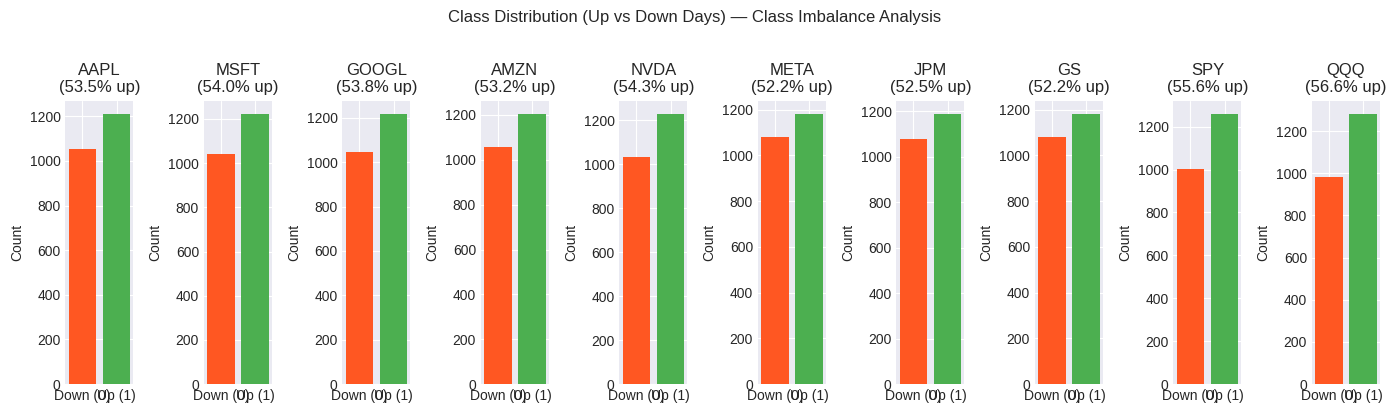

In [30]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(14, 4))

for i, ticker in enumerate(TICKERS):
    ohlcv, _ = preprocessor.preprocess_prices(prices, ticker)
    labels = (ohlcv['LogReturn'] > 0).astype(int).values
    counts = np.bincount(labels)
    pct_up = counts[1] / len(labels)

    axes[i].bar(['Down (0)', 'Up (1)'], counts, color=['#FF5722', '#4CAF50'])
    axes[i].set_title(f'{ticker}\n({pct_up:.1%} up)')
    axes[i].set_ylabel('Count')

    class_weights = preprocessor.compute_class_weights(labels)
    print(f'{ticker}: up={pct_up:.1%}, class_weights={dict(zip([0,1], class_weights.round(3)))}')

plt.suptitle('Class Distribution (Up vs Down Days) — Class Imbalance Analysis', y=1.02)
plt.tight_layout()
plt.savefig('/docs/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

Feature engineering - Technical Indicators

In [31]:
# Demonstrate technical indicator computation
aapl_ohlcv, _ = preprocessor.preprocess_prices(prices, 'AAPL')
features = TechnicalIndicators.compute_all(aapl_ohlcv)

print(f'Technical features computed: {features.shape[1]} features')
print(f'Feature names: {features.columns.tolist()}')
print(f'\nFirst few rows (after NaN period):')
print(features.dropna().head(3).to_string())

Technical features computed: 20 features
Feature names: ['LogReturn_1d', 'LogReturn_5d', 'LogReturn_20d', 'HighLow_Range', 'CloseOpen_Gap', 'RSI_14', 'RSI_7', 'MACD', 'MACD_Signal', 'MACD_Hist', 'ROC_10', 'ROC_5', 'BB_PctB', 'BB_Bandwidth', 'ATR_14', 'HV_20', 'SMA_Ratio_10_50', 'EMA_Ratio_12_26', 'OBV_Norm', 'Volume_Ratio']

First few rows (after NaN period):
            LogReturn_1d  LogReturn_5d  LogReturn_20d  HighLow_Range  CloseOpen_Gap     RSI_14      RSI_7      MACD  MACD_Signal  MACD_Hist    ROC_10     ROC_5   BB_PctB  BB_Bandwidth    ATR_14     HV_20  SMA_Ratio_10_50  EMA_Ratio_12_26  OBV_Norm  Volume_Ratio
Date                                                                                                                                                                                                                                                                 
2017-07-10      0.006085      0.007195      -0.026665       0.017786       0.006571  50.925672  61.841628 -0.34825

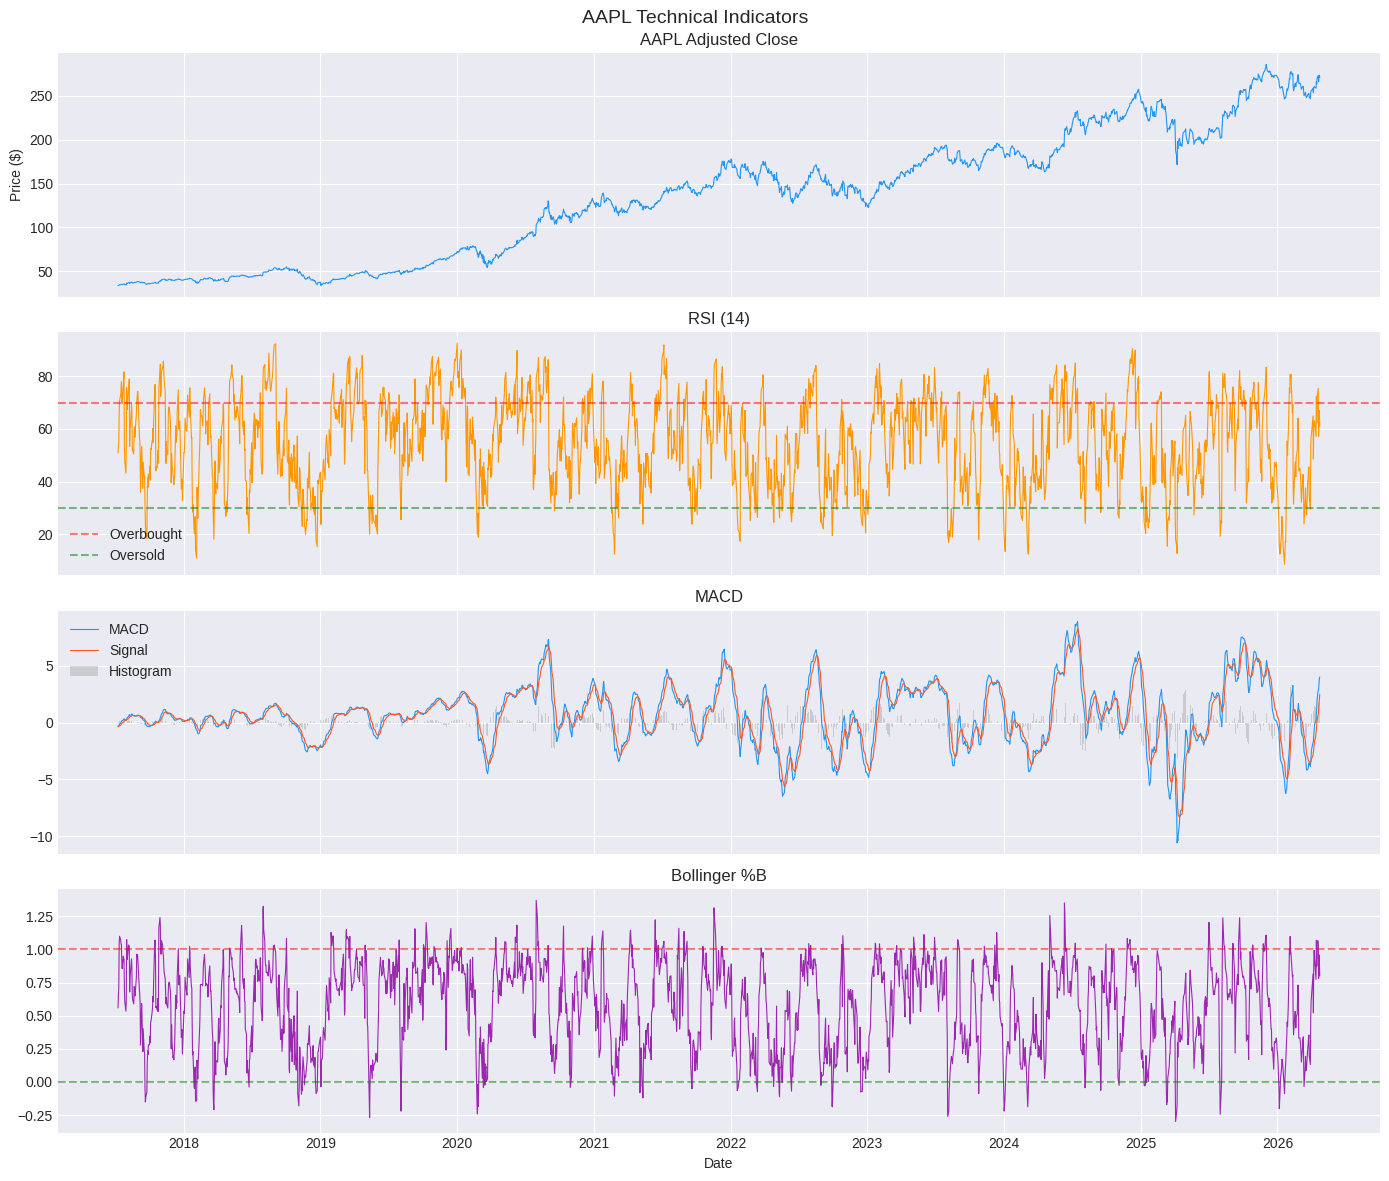

In [32]:
# Plot key technical indicators for AAPL
feat_clean = features.dropna()
close = aapl_ohlcv['Close'].loc[feat_clean.index]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(close.index, close.values, color='#2196F3', linewidth=0.8)
axes[0].set_title('AAPL Adjusted Close')
axes[0].set_ylabel('Price ($)')

axes[1].plot(feat_clean.index, feat_clean['RSI_14'], color='#FF9800', linewidth=0.8)
axes[1].axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought')
axes[1].axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold')
axes[1].set_title('RSI (14)')
axes[1].legend()

axes[2].plot(feat_clean.index, feat_clean['MACD'], color='#2196F3', label='MACD', linewidth=0.8)
axes[2].plot(feat_clean.index, feat_clean['MACD_Signal'], color='#FF5722', label='Signal', linewidth=0.8)
axes[2].bar(feat_clean.index, feat_clean['MACD_Hist'], color='gray', alpha=0.3, label='Histogram')
axes[2].set_title('MACD')
axes[2].legend()

axes[3].plot(feat_clean.index, feat_clean['BB_PctB'], color='#9C27B0', linewidth=0.8)
axes[3].axhline(1.0, color='red', linestyle='--', alpha=0.5)
axes[3].axhline(0.0, color='green', linestyle='--', alpha=0.5)
axes[3].set_title('Bollinger %B')

axes[-1].set_xlabel('Date')
plt.suptitle('AAPL Technical Indicators', fontsize=14)
plt.tight_layout()
plt.savefig('/docs/technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

Train/test/val split

Total samples: 2211
Train: 1547 samples (70.0%) | 2017-07-10 to 2023-08-30
Val:   332 samples (15.0%) | 2023-08-31 to 2024-12-24
Test:  332 samples (15.0%) | 2024-12-26 to 2026-04-24


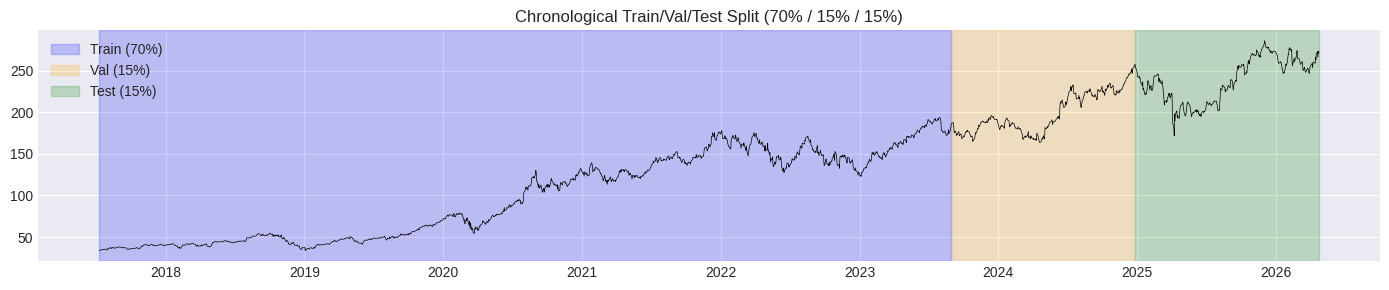

In [33]:
# Demonstrate the chronological split
full_df = feat_clean.join(aapl_ohlcv[['LogReturn']], how='inner').dropna()
train_df, val_df, test_df = preprocessor.train_val_test_split(full_df)

print(f'Total samples: {len(full_df)}')
print(f'Train: {len(train_df)} samples ({len(train_df)/len(full_df):.1%}) | {train_df.index[0].date()} to {train_df.index[-1].date()}')
print(f'Val:   {len(val_df)} samples ({len(val_df)/len(full_df):.1%}) | {val_df.index[0].date()} to {val_df.index[-1].date()}')
print(f'Test:  {len(test_df)} samples ({len(test_df)/len(full_df):.1%}) | {test_df.index[0].date()} to {test_df.index[-1].date()}')

# Visualize the split
fig, ax = plt.subplots(figsize=(14, 3))
ax.axvspan(train_df.index[0], train_df.index[-1], alpha=0.2, color='blue', label=f'Train (70%)')
ax.axvspan(val_df.index[0], val_df.index[-1], alpha=0.2, color='orange', label=f'Val (15%)')
ax.axvspan(test_df.index[0], test_df.index[-1], alpha=0.2, color='green', label=f'Test (15%)')
close_plot = aapl_ohlcv['Close'].loc[full_df.index]
ax.plot(close_plot.index, close_plot.values, color='black', linewidth=0.5)
ax.set_title('Chronological Train/Val/Test Split (70% / 15% / 15%)')
ax.legend()
plt.tight_layout()
plt.savefig('/docs/data_split.png', dpi=150, bbox_inches='tight')
plt.show()

Feature correlation analysis

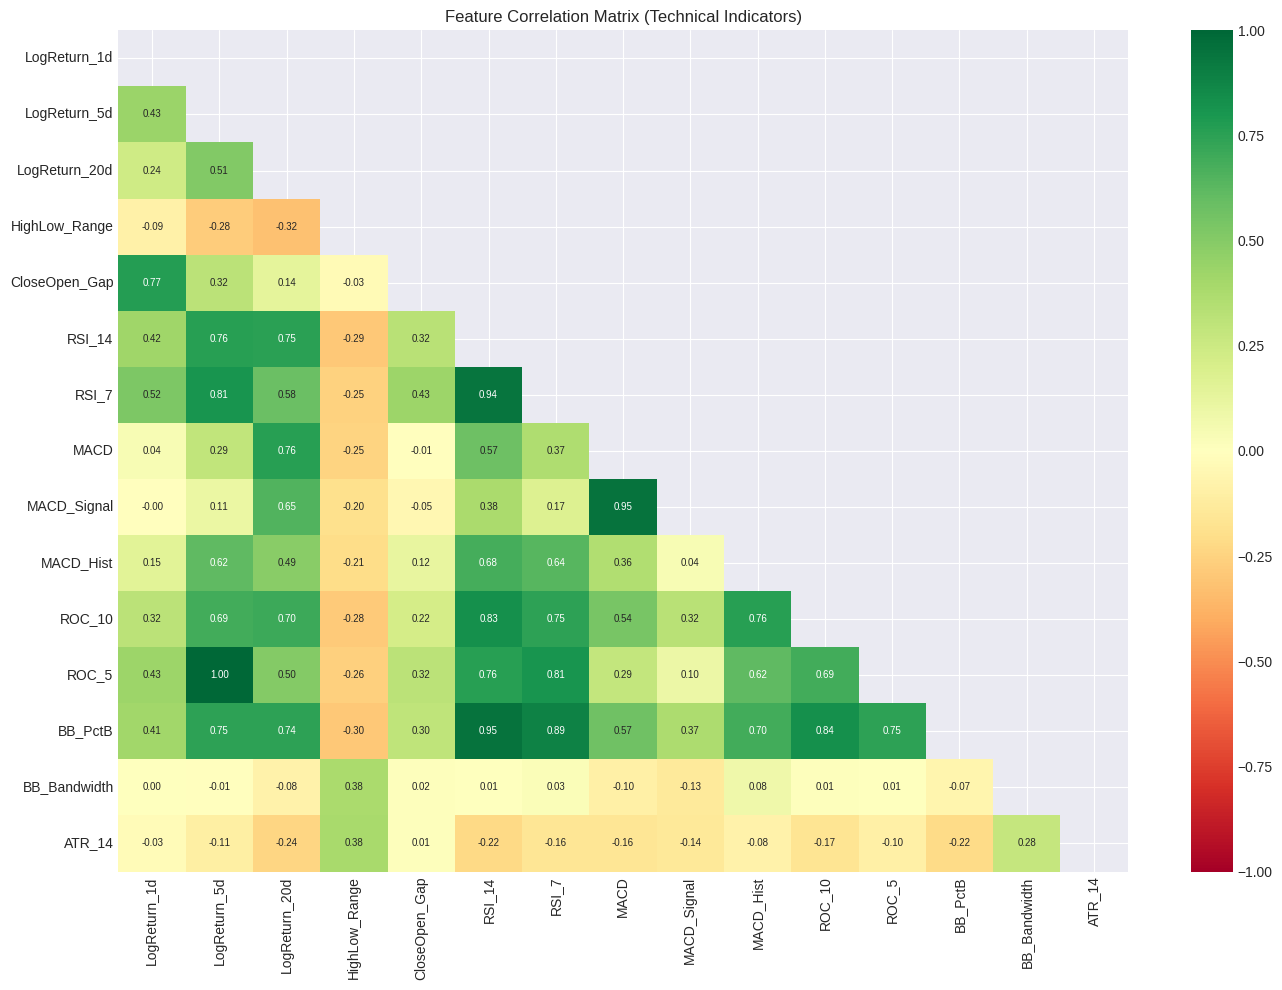


Data exploration complete. All visualizations saved to docs/


In [34]:
# Correlation heatmap of technical features
fig, ax = plt.subplots(figsize=(14, 10))
corr = feat_clean.iloc[:, :15].corr()  # first 15 features for readability
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (Technical Indicators)')
plt.tight_layout()
plt.savefig('/docs/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nData exploration complete. All visualizations saved to docs/')

# News Collections and Sentiment Analysis

In [5]:
from src.models.sentiment import SentimentAnalyzer

# Fetch recent headlines for all tickers via Yahoo Finance news endpoint
news_df = collector.collect_all_news(n_articles_per_ticker=30, prices=prices, force_refresh=True)
print(f"Headlines collected: {len(news_df)}")
print(news_df[["ticker","title","published_at"]].head(8).to_string(index=False))

Headlines collected: 70
ticker                                                                              title published_at
  AAPL Leaders come and go; companies rise and fall. In business, change is the constant.   2026-04-26
  AAPL                         Boston Trust Walden Lets Go of 93,000 Qualys (QLYS) Shares   2026-04-26
  AAPL                            Does a Merger With iHeartRadio Make Sirius Stock a Buy?   2026-04-26
  AAPL                  Five Big Tech Earnings Could Decide Bitcoin’s Next Move This Week   2026-04-26
  AAPL                                                                   Apple’s New Boss   2026-04-26
  AAPL        Dow Jones Futures: Iran Talks Off; Apple, Amazon, Google Lead Earnings Wave   2026-04-26
  AAPL                   Big Tech’s $16 Trillion Earnings Week Is Make-Or-Break for Rally   2026-04-26
  AAPL               AEye Shares Surge On Key Executive Hire: What Investors Need To Know   2026-04-26


In [18]:
from google.colab import userdata
import os
os.environ["ANTHROPIC_API_KEY"] = ""

In [19]:
# Score headlines — uses Claude API if ANTHROPIC_API_KEY is set, else rule-based fallback
analyzer = SentimentAnalyzer()
print(f"Using Claude API: {not analyzer._use_fallback}")

# Show a sample of scored headlines
sample = news_df["title"].dropna().head(6).tolist()
sample_scores = analyzer.score_batch(sample)
sample_df = pd.DataFrame(sample_scores)[["headline","sentiment","score","confidence"]]
print("Sample sentiment scores:")
print(sample_df.to_string(index=False))

Using Claude API: False
Sample sentiment scores:
                                                                          headline sentiment  score  confidence
Leaders come and go; companies rise and fall. In business, change is the constant.  positive    1.0         0.6
                        Boston Trust Walden Lets Go of 93,000 Qualys (QLYS) Shares   neutral    0.0         0.6
                           Does a Merger With iHeartRadio Make Sirius Stock a Buy?   neutral    0.0         0.6
                 Five Big Tech Earnings Could Decide Bitcoin’s Next Move This Week   neutral    0.0         0.6
                                                                  Apple’s New Boss   neutral    0.0         0.6
       Dow Jones Futures: Iran Talks Off; Apple, Amazon, Google Lead Earnings Wave   neutral    0.0         0.6


In [20]:
# Aggregate to daily per-ticker sentiment scores (confidence-weighted mean)
daily_sentiment = analyzer.aggregate_daily_sentiment(news_df, TICKERS)
print(f"Daily sentiment records: {len(daily_sentiment)}")
print(daily_sentiment.head(10).to_string(index=False))

# Save for use in notebooks 2, 3, 4
import os; os.makedirs("../data", exist_ok=True)
daily_sentiment.to_csv("../data/daily_sentiment.csv", index=False)
print("Saved to ../data/daily_sentiment.csv")

Daily sentiment records: 18
ticker       date  sentiment_score  n_articles
  AAPL 2026-04-25         0.600000           1
  AAPL 2026-04-26         0.266667           9
  AMZN 2026-04-26         0.000000           5
 GOOGL 2026-04-26         0.150000           4
    GS 2026-04-24        -0.300000           2
    GS 2026-04-25         0.000000           5
    GS 2026-04-26         0.000000           2
   JPM 2026-04-25         0.000000           8
   JPM 2026-04-26         0.600000           2
  META 2026-04-26         0.200000           3
Saved to ../data/daily_sentiment.csv


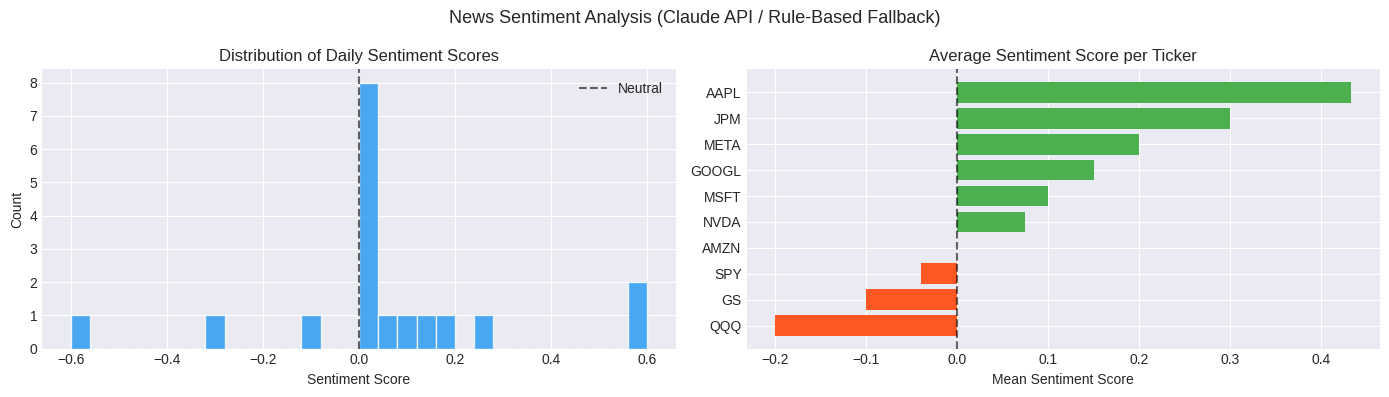

Sentiment analysis complete.


In [21]:
# Visualise sentiment distribution and per-ticker averages
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(daily_sentiment["sentiment_score"].dropna(), bins=30,
             color="#2196F3", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="black", linestyle="--", alpha=0.6, label="Neutral")
axes[0].set_xlabel("Sentiment Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Daily Sentiment Scores")
axes[0].legend()

avg_sent = daily_sentiment.groupby("ticker")["sentiment_score"].mean().sort_values()
bar_colors = ["#FF5722" if v < 0 else "#4CAF50" for v in avg_sent.values]
axes[1].barh(avg_sent.index, avg_sent.values, color=bar_colors)
axes[1].axvline(0, color="black", linestyle="--", alpha=0.6)
axes[1].set_xlabel("Mean Sentiment Score")
axes[1].set_title("Average Sentiment Score per Ticker")

plt.suptitle("News Sentiment Analysis (Claude API / Rule-Based Fallback)", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/sentiment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sentiment analysis complete.")